# Homework 4 Solution

In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
sns.set_palette("husl")
plt.rcParams.update(
    {
        "figure.facecolor": "#111111",
        "axes.facecolor": "#111111",
        "axes.edgecolor": "#aaaaaa",
        "text.color": "#ffffff",
        "xtick.color": "#aaaaaa",
        "ytick.color": "#aaaaaa",
    }
)

os.makedirs("./figures", exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, nnls
from sklearn.linear_model import Lasso, LassoCV

In [3]:
def basis(x, knots):
    """Build the basis matrix. One extra column per knot."""
    cols = [np.ones_like(x), x] + [np.clip(x - k, 0.0, None) for k in knots]
    return np.column_stack(cols)


def knots(K):
    """K knots, evenly spaced inside (0, 1)."""
    return np.linspace(0, 1, K + 2)[1:-1]


def fit_ols(A, y):
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    return beta

## Problem 1

In [4]:
N_TRAIN, N_TEST = 60, 500
SIGMA = 0.3
K_MAX = 18
N_REPS = 600

x_train = np.linspace(0, 1, N_TRAIN)
x_test = np.linspace(0.005, 0.995, N_TEST)


def f_true(x):
    return np.sin(2 * np.pi * x)

### 1.1

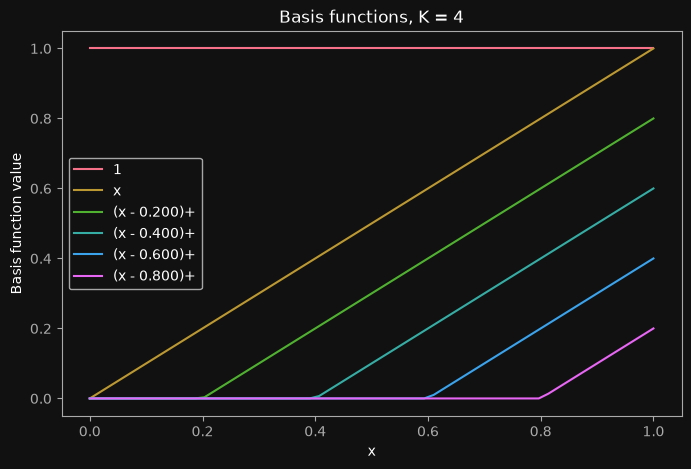

In [5]:
A_demo = basis(x_train, knots(4))

fig, ax = plt.subplots(figsize=(8, 5))
labels = ["1", "x"] + [f"(x - {k:.3f})+" for k in knots(4)]
for j in range(A_demo.shape[1]):
    ax.plot(x_train, A_demo[:, j], label=labels[j])
ax.set_xlabel("x")
ax.set_ylabel("Basis function value")
ax.set_title("Basis functions, K = 4")
ax.legend()
fig.savefig("./figures/problem1_basis.png", dpi=300, bbox_inches="tight")

### 1.2

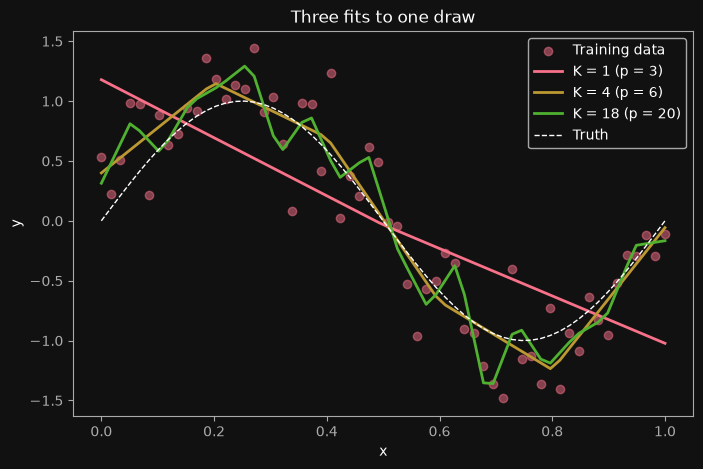

In [6]:
rng = np.random.RandomState(0)
y_train_demo = f_true(x_train) + rng.normal(0, SIGMA, N_TRAIN)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_train, y_train_demo, alpha=0.5, label="Training data")
for K in (1, 4, 18):
    A = basis(x_train, knots(K))
    ax.plot(x_train, A @ fit_ols(A, y_train_demo), lw=2, label=f"K = {K} (p = {2 + K})")
ax.plot(x_train, f_true(x_train), color="white", ls="--", lw=1, label="Truth")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Three fits to one draw")
ax.legend()
fig.savefig("./figures/problem1_three_fits.png", dpi=300, bbox_inches="tight")

### 1.3

`K_MAX = 18` and `N_REPS = 600` are the values given with the problem, so the table
runs to `K = 18` rather than `K = 30`, over 600 repetitions.

\begin{tabular}{lrrr}
\toprule
 & p & training MSE & test MSE \\
K &  &  &  \\
\midrule
0 & 2 & 0.2963 & 0.2846 \\
2 & 4 & 0.1003 & 0.1113 \\
3 & 5 & 0.0881 & 0.1029 \\
4 & 6 & 0.0827 & 0.1007 \\
5 & 7 & 0.0802 & 0.1010 \\
10 & 12 & 0.0718 & 0.1073 \\
15 & 17 & 0.0644 & 0.1147 \\
18 & 20 & 0.0599 & 0.1192 \\
\bottomrule
\end{tabular}



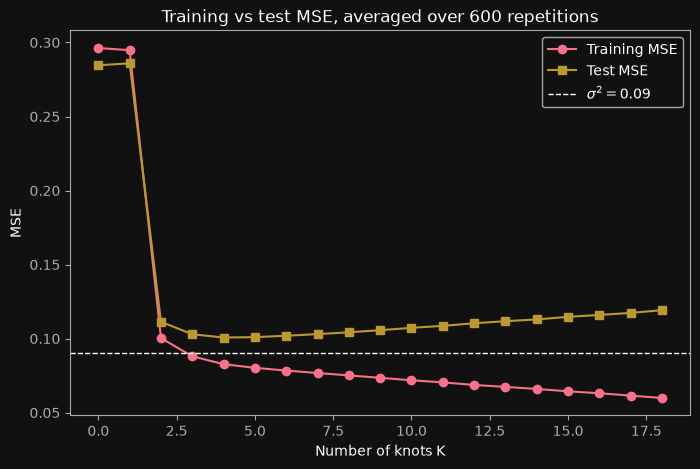

In [7]:
A_train = {K: basis(x_train, knots(K)) for K in range(K_MAX + 1)}
A_test = {K: basis(x_test, knots(K)) for K in range(K_MAX + 1)}

ins_all, oos_all = [], []
for s in range(N_REPS):
    rng = np.random.RandomState(s)
    y_tr = f_true(x_train) + rng.normal(0, SIGMA, N_TRAIN)
    y_te = f_true(x_test) + rng.normal(0, SIGMA, N_TEST)
    ins_row, oos_row = [], []
    for K in range(K_MAX + 1):
        beta = fit_ols(A_train[K], y_tr)
        ins_row.append(np.mean((A_train[K] @ beta - y_tr) ** 2))
        oos_row.append(np.mean((A_test[K] @ beta - y_te) ** 2))
    ins_all.append(ins_row)
    oos_all.append(oos_row)

in_sample = np.mean(ins_all, axis=0)
out_sample = np.mean(oos_all, axis=0)
Ks = np.arange(K_MAX + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Ks, in_sample, marker="o", label="Training MSE")
ax.plot(Ks, out_sample, marker="s", label="Test MSE")
ax.axhline(SIGMA**2, color="white", ls="--", lw=1, label="$\\sigma^2 = 0.09$")
ax.set_xlabel("Number of knots K")
ax.set_ylabel("MSE")
ax.set_title("Training vs test MSE, averaged over 600 repetitions")
ax.legend()
fig.savefig("./figures/problem1_mse_curves.png", dpi=300, bbox_inches="tight")

summary1 = pd.DataFrame(
    {"K": Ks, "p": 2 + Ks, "training MSE": in_sample, "test MSE": out_sample}
).set_index("K")
print(summary1.loc[[0, 2, 3, 4, 5, 10, 15, 18]].to_latex(float_format="{:0.4f}".format))

### 1.4

In [8]:
k_best = int(np.argmin(out_sample))
print("training MSE strictly decreasing:", bool(np.all(np.diff(in_sample) < 0)))
print(f"training MSE falls from {in_sample[0]:.4f} to {in_sample[-1]:.4f}")
print("test MSE strictly increasing after the minimum:", bool(np.all(np.diff(out_sample[k_best:]) > 0)))
print(f"test MSE minimized at K = {k_best} (p = {2 + k_best}), value {out_sample[k_best]:.4f}")
print(f"test MSE at K = {K_MAX} is {out_sample[K_MAX]:.4f}, {out_sample[K_MAX] / out_sample[k_best]:.2f}x the minimum")

training MSE strictly decreasing: True
training MSE falls from 0.2963 to 0.0599
test MSE strictly increasing after the minimum: True
test MSE minimized at K = 4 (p = 6), value 0.1007
test MSE at K = 18 is 0.1192, 1.18x the minimum


### 1.5

\begin{tabular}{lrrr}
\toprule
 & simulated & theory & pct gap \\
K &  &  &  \\
\midrule
0 & 0.2846 & 0.0930 & 206.0164 \\
2 & 0.1113 & 0.0960 & 15.9788 \\
3 & 0.1029 & 0.0975 & 5.5749 \\
4 & 0.1007 & 0.0990 & 1.7433 \\
5 & 0.1010 & 0.1005 & 0.4737 \\
10 & 0.1073 & 0.1080 & -0.6921 \\
15 & 0.1147 & 0.1155 & -0.6987 \\
18 & 0.1192 & 0.1200 & -0.6822 \\
\bottomrule
\end{tabular}

simulation within 3% of theory for K = 4 to 18
  gap at K=3: 5.57% (outside)
  gap at K=4: 1.74% (inside)


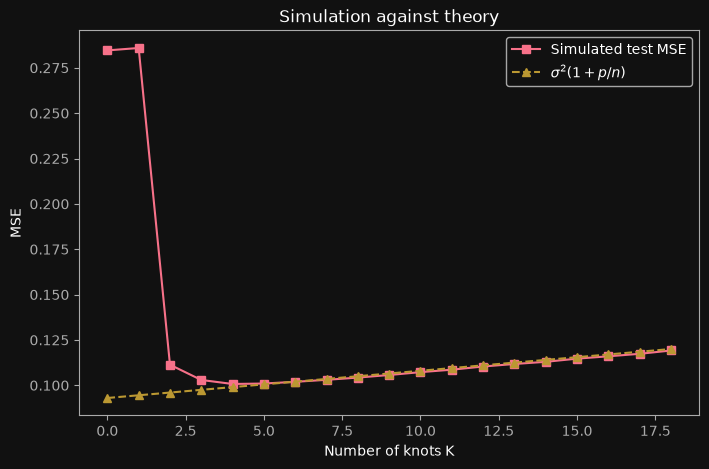

In [9]:
theory = SIGMA**2 * (1 + (2 + Ks) / N_TRAIN)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Ks, out_sample, marker="s", label="Simulated test MSE")
ax.plot(Ks, theory, marker="^", ls="--", label="$\\sigma^2 (1 + p/n)$")
ax.set_xlabel("Number of knots K")
ax.set_ylabel("MSE")
ax.set_title("Simulation against theory")
ax.legend()
fig.savefig("./figures/problem1_theory.png", dpi=300, bbox_inches="tight")

comp = pd.DataFrame(
    {
        "K": Ks,
        "simulated": out_sample,
        "theory": theory,
        "pct gap": 100 * (out_sample / theory - 1),
    }
).set_index("K")
print(comp.loc[[0, 2, 3, 4, 5, 10, 15, 18]].to_latex(float_format="{:0.4f}".format))

within3 = [int(k) for k in Ks if abs(out_sample[k] / theory[k] - 1) <= 0.03]
print(f"simulation within 3% of theory for K = {min(within3)} to {max(within3)}")
print(f"  gap at K={min(within3) - 1}: {100 * (out_sample[min(within3) - 1] / theory[min(within3) - 1] - 1):.2f}% (outside)")
print(f"  gap at K={min(within3)}: {100 * (out_sample[min(within3)] / theory[min(within3)] - 1):.2f}% (inside)")

## Problem 2

In [10]:
TRUE_KNOTS = [0.3, 0.7]
TRUE_BETA = np.array([0.0, 2.0, -8.0, 10.0])
CANDIDATE_KNOTS = np.linspace(0.05, 0.95, 19)
N2, SIGMA2 = 200, 0.3

rng = np.random.RandomState(7)
x2 = rng.uniform(0, 1, N2)
y2 = basis(x2, TRUE_KNOTS) @ TRUE_BETA + rng.normal(0, SIGMA2, N2)

A_full = basis(x2, CANDIDATE_KNOTS)
design = A_full[:, 1:]

### 2.1

largest |coef| among the 19 knot terms: 23.28
true slope changes: -8.0, 10.0
ratio to the largest true slope change: 2.33
knot coefficients:
[ 1.055e+01 -5.720e+00  2.000e-02  4.350e+00 -4.740e+00 -8.030e+00
 -1.350e+00  6.820e+00  1.500e+00 -1.080e+01  9.510e+00 -4.710e+00
 -3.560e+00  2.328e+01 -1.332e+01  8.000e-01  1.560e+00  7.560e+00
 -1.144e+01]


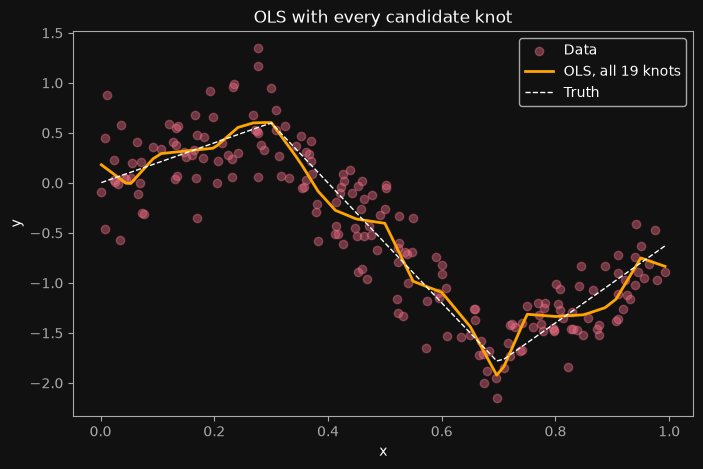

In [11]:
beta_ols = fit_ols(A_full, y2)
print(f"largest |coef| among the 19 knot terms: {np.max(np.abs(beta_ols[2:])):.2f}")
print(f"true slope changes: {TRUE_BETA[2]}, {TRUE_BETA[3]}")
print(f"ratio to the largest true slope change: {np.max(np.abs(beta_ols[2:])) / 10:.2f}")
print("knot coefficients:")
print(np.round(beta_ols[2:], 2))

order = np.argsort(x2)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x2, y2, alpha=0.4, label="Data")
ax.plot(x2[order], (A_full @ beta_ols)[order], color="orange", lw=2, label="OLS, all 19 knots")
ax.plot(
    x2[order],
    (basis(x2, TRUE_KNOTS) @ TRUE_BETA)[order],
    color="white",
    ls="--",
    lw=1,
    label="Truth",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("OLS with every candidate knot")
ax.legend()
fig.savefig("./figures/problem2_ols_fit.png", dpi=300, bbox_inches="tight")

### 2.2

In [12]:
lcv = LassoCV(cv=5, random_state=0, max_iter=200000).fit(design, y2)
kept = [
    round(float(CANDIDATE_KNOTS[i - 1]), 3)
    for i in range(1, design.shape[1])
    if abs(lcv.coef_[i]) > 1e-8
]
print(f"selected alpha = {lcv.alpha_:.5f}")
print(f"knots kept ({len(kept)} of 19): {kept}")
print(f"true knots: {TRUE_KNOTS}")

selected alpha = 0.00054
knots kept (4 of 19): [0.05, 0.25, 0.3, 0.7]
true knots: [0.3, 0.7]


### 2.3

In [13]:
alphas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
rows = []
for a in alphas:
    la = Lasso(alpha=a, max_iter=200000).fit(design, y2)
    sel = [
        round(float(CANDIDATE_KNOTS[i - 1]), 3)
        for i in range(1, design.shape[1])
        if abs(la.coef_[i]) > 1e-8
    ]
    rows.append({"alpha": a, "n_selected": len(sel), "knots": str(sel)})
print(pd.DataFrame(rows).to_string(index=False))

 alpha  n_selected            knots
 0.001           2       [0.3, 0.7]
 0.005           3 [0.25, 0.3, 0.7]
 0.010           3 [0.2, 0.25, 0.7]
 0.020           2      [0.15, 0.2]
 0.050           2      [0.1, 0.15]
 0.100           0               []


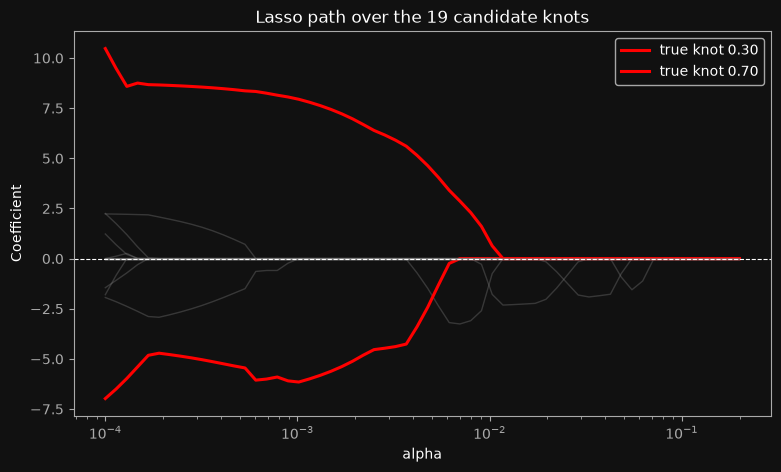

In [14]:
grid_alphas = np.logspace(-4, -0.7, 60)
coefs = np.array(
    [Lasso(alpha=a, max_iter=200000).fit(design, y2).coef_[1:] for a in grid_alphas]
)

fig, ax = plt.subplots(figsize=(9, 5))
for j, k in enumerate(CANDIDATE_KNOTS):
    is_true = bool(np.any(np.isclose(k, TRUE_KNOTS)))
    ax.plot(
        grid_alphas,
        coefs[:, j],
        lw=2.2 if is_true else 1.0,
        color="red" if is_true else "grey",
        alpha=1.0 if is_true else 0.35,
        label=f"true knot {k:.2f}" if is_true else None,
    )
ax.set_xscale("log")
ax.axhline(0, color="white", lw=0.8, ls="--")
ax.set_xlabel("alpha")
ax.set_ylabel("Coefficient")
ax.set_title("Lasso path over the 19 candidate knots")
ax.legend()
fig.savefig("./figures/problem2_lasso_path.png", dpi=300, bbox_inches="tight")

### 2.4

Written answer only; see the write-up.

## Problem 3

In [15]:
def lognormal_basis(tau, mu, s):
    """A Gaussian bump in log-tenor space: narrow at the front, wide at the back."""
    return np.exp(-((np.log(tau) - mu) ** 2) / (2 * s**2))


TENORS = np.array(
    [0.25, 0.5, 0.75, 1, 2, 3, 4, 5, 7, 10, 12, 15, 20, 25, 30], dtype=float
)
CENTRES = np.log(np.array([0.5, 1.5, 4.0, 12.0, 30.0]))
WIDTH = 0.9


def true_curve(tau):
    return 0.02 + 0.01 * np.sqrt(tau)


rng = np.random.RandomState(0)
y3 = true_curve(TENORS) + rng.normal(0, 0.0004, len(TENORS))

tau_fine = np.linspace(0.25, 30, 500)


def ln_design(tau):
    return np.column_stack([lognormal_basis(tau, m, WIDTH) for m in CENTRES])


A3 = ln_design(TENORS)
F3 = ln_design(tau_fine)

### 3.1

 centre_y  grid_lo  grid_hi  grid_width  exact_lo  exact_hi  exact_width
     0.50     0.25     1.44        1.19      0.17      1.44         1.27
     1.50     0.55     4.30        3.76      0.52      4.33         3.81
     4.00     1.44    11.52       10.08      1.39     11.54        10.16
    12.00     4.18    30.00       25.82      4.16     34.62        30.47
    30.00    10.44    30.00       19.56     10.40     86.56        76.17

tau_fine spans 0.25 to 30, so any range touching either end is clipped.


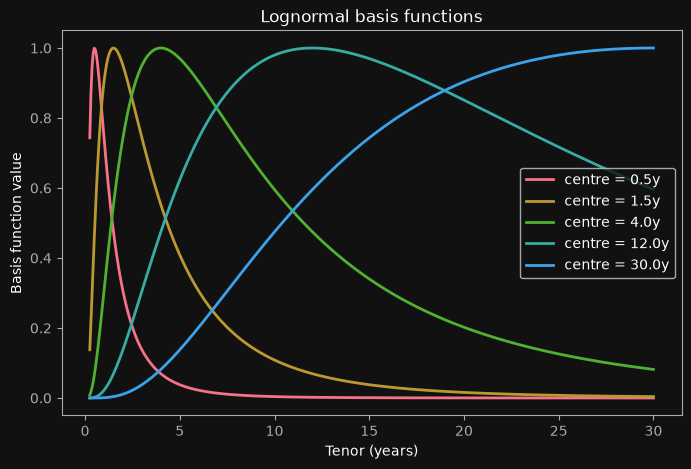

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
for m in CENTRES:
    ax.plot(tau_fine, lognormal_basis(tau_fine, m, WIDTH), lw=2, label=f"centre = {np.exp(m):.1f}y")
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Basis function value")
ax.set_title("Lognormal basis functions")
ax.legend()
fig.savefig("./figures/problem3_basis.png", dpi=300, bbox_inches="tight")

# Half-max range. Measured on tau_fine, and analytically:
# phi = 0.5 when (log tau - mu)^2 = 2 s^2 log 2, i.e. tau = exp(mu +/- s sqrt(2 log 2)).
half = WIDTH * np.sqrt(2 * np.log(2))
widths = []
for m in CENTRES:
    above = tau_fine[lognormal_basis(tau_fine, m, WIDTH) >= 0.5]
    widths.append(
        {
            "centre_y": float(np.exp(m)),
            "grid_lo": above.min(),
            "grid_hi": above.max(),
            "grid_width": above.max() - above.min(),
            "exact_lo": np.exp(m - half),
            "exact_hi": np.exp(m + half),
            "exact_width": np.exp(m + half) - np.exp(m - half),
        }
    )
print(pd.DataFrame(widths).to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print()
print("tau_fine spans 0.25 to 30, so any range touching either end is clipped.")

### 3.2

In [17]:
w_ols3 = fit_ols(A3, y3)

print(f"OLS weights: {np.round(w_ols3, 5)}")
print(f"negative weights: {int(np.sum(w_ols3 < 0))} of {len(w_ols3)}  (min {w_ols3.min():.5f})")
print(f"SSE = {np.sum((A3 @ w_ols3 - y3) ** 2):.4e}")
print(f"RMSE vs true curve = {np.sqrt(np.mean((F3 @ w_ols3 - true_curve(tau_fine)) ** 2)) * 1e4:.2f} bp")

OLS weights: [ 0.03083 -0.00688  0.04134 -0.00927  0.0743 ]
negative weights: 2 of 5  (min -0.00927)
SSE = 5.2294e-05
RMSE vs true curve = 16.70 bp


### 3.3

In [18]:
res3 = minimize(
    lambda w: np.sum((A3 @ w - y3) ** 2),
    np.maximum(w_ols3, 0.0),
    method="L-BFGS-B",
    bounds=[(0.0, None)] * A3.shape[1],
    options={"maxiter": 100000, "ftol": 1e-18, "gtol": 1e-14},
)
w_nn = res3.x

print(f"success = {res3.success}")
print(f"weights: {np.round(w_nn, 5)}")
print(f"weights exactly zero: {int(np.sum(w_nn < 1e-10))}")
print(f"RMSE vs true curve = {np.sqrt(np.mean((F3 @ w_nn - true_curve(tau_fine)) ** 2)) * 1e4:.2f} bp")
print(f"SSE ratio against y3 (new / OLS) = {np.sum((A3 @ w_nn - y3) ** 2) / np.sum((A3 @ w_ols3 - y3) ** 2):.3f}")

success = True
weights: [0.02765 0.      0.03268 0.      0.06763]
weights exactly zero: 2
RMSE vs true curve = 19.87 bp
SSE ratio against y3 (new / OLS) = 1.373


In [19]:
# Cross-check against the dedicated non-negative least squares solver.
w_check, _ = nnls(A3, y3)
print(f"scipy.optimize.nnls: {np.round(w_check, 5)}")
print(f"max abs difference: {np.max(np.abs(w_nn - w_check)):.2e}")

scipy.optimize.nnls: [0.02765 0.      0.03268 0.      0.06763]
max abs difference: 4.05e-09


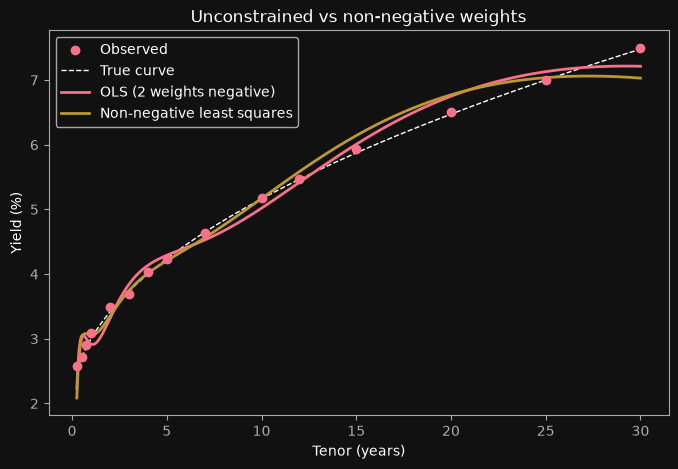

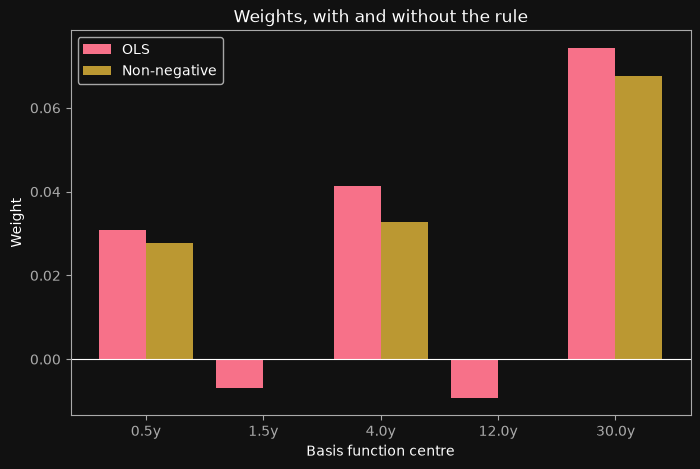

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(TENORS, y3 * 100, zorder=3, label="Observed")
ax.plot(tau_fine, true_curve(tau_fine) * 100, color="white", ls="--", lw=1, label="True curve")
ax.plot(tau_fine, (F3 @ w_ols3) * 100, lw=2, label="OLS (2 weights negative)")
ax.plot(tau_fine, (F3 @ w_nn) * 100, lw=2, label="Non-negative least squares")
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Yield (%)")
ax.set_title("Unconstrained vs non-negative weights")
ax.legend()
fig.savefig("./figures/problem3_fits.png", dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(8, 5))
idx = np.arange(len(CENTRES))
ax.bar(idx - 0.2, w_ols3, width=0.4, label="OLS")
ax.bar(idx + 0.2, w_nn, width=0.4, label="Non-negative")
ax.axhline(0, color="white", lw=0.8)
ax.set_xticks(idx)
ax.set_xticklabels([f"{np.exp(m):.1f}y" for m in CENTRES])
ax.set_xlabel("Basis function centre")
ax.set_ylabel("Weight")
ax.set_title("Weights, with and without the rule")
ax.legend()
fig.savefig("./figures/problem3_weights.png", dpi=300, bbox_inches="tight")

## Problem 4

In [21]:
x4 = np.linspace(0, 1, 120)
clean_curve = np.sin(2 * np.pi * x4)

rng = np.random.RandomState(5)
y4 = clean_curve + rng.normal(0, 0.05, 120)
bad_idx = rng.choice(120, 8, replace=False)
y4[bad_idx] += rng.choice([-1, 1], 8) * 1.5

B4 = basis(x4, knots(8))
OPT = {"maxiter": 50000, "maxfun": 200000, "ftol": 1e-15, "gtol": 1e-12}
EPS = 1e-3
print("bad indices:", np.sort(bad_idx))

bad indices: [21 41 48 63 65 66 95 98]


### 4.1

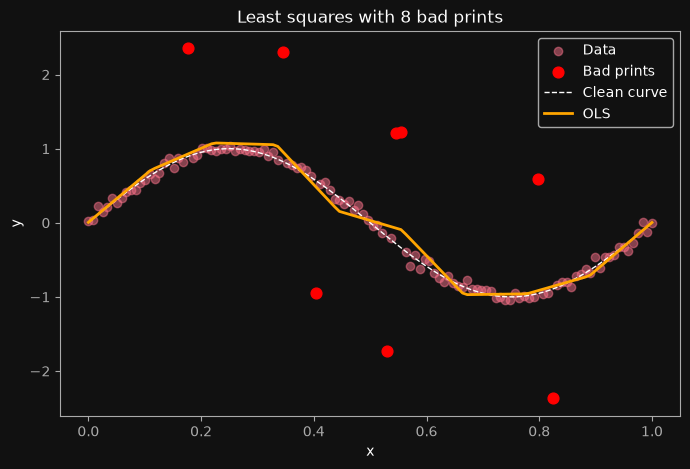

In [22]:
w_ols = fit_ols(B4, y4)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x4, y4, alpha=0.5, label="Data")
ax.scatter(x4[bad_idx], y4[bad_idx], color="red", s=60, zorder=3, label="Bad prints")
ax.plot(x4, clean_curve, color="white", ls="--", lw=1, label="Clean curve")
ax.plot(x4, B4 @ w_ols, color="orange", lw=2, label="OLS")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Least squares with 8 bad prints")
ax.legend()
fig.savefig("./figures/problem4_ols.png", dpi=300, bbox_inches="tight")

### 4.2

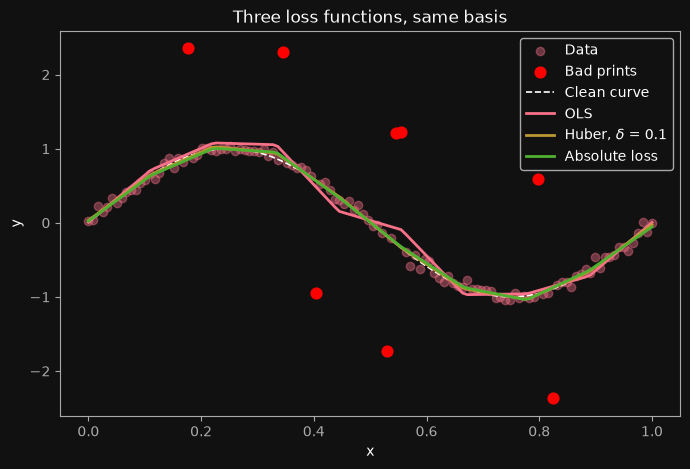

In [23]:
def huber_loss(r, delta):
    a = np.abs(r)
    return np.where(a <= delta, 0.5 * r**2, delta * (a - 0.5 * delta))


w_huber = minimize(
    lambda w: np.sum(huber_loss(B4 @ w - y4, 0.1)), w_ols, method="L-BFGS-B", options=OPT
).x
# |r| has a sharp corner at 0 that a solver cannot follow, so smooth it slightly
w_abs = minimize(
    lambda w: np.sum(np.sqrt((B4 @ w - y4) ** 2 + EPS**2)),
    w_ols,
    method="L-BFGS-B",
    options=OPT,
).x

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x4, y4, alpha=0.4, label="Data")
ax.scatter(x4[bad_idx], y4[bad_idx], color="red", s=60, zorder=3, label="Bad prints")
ax.plot(x4, clean_curve, color="white", ls="--", lw=1.2, label="Clean curve")
ax.plot(x4, B4 @ w_ols, lw=2, label="OLS")
ax.plot(x4, B4 @ w_huber, lw=2, label="Huber, $\\delta$ = 0.1")
ax.plot(x4, B4 @ w_abs, lw=2, label="Absolute loss")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Three loss functions, same basis")
ax.legend()
fig.savefig("./figures/problem4_losses.png", dpi=300, bbox_inches="tight")

### 4.3

In [24]:
rows = []
for nm, w in (("OLS", w_ols), ("Huber (delta=0.1)", w_huber), ("absolute", w_abs)):
    rows.append(
        {
            "loss": nm,
            "rmse_vs_clean": np.sqrt(np.mean((B4 @ w - clean_curve) ** 2)),
            "rmse_vs_y4": np.sqrt(np.mean((B4 @ w - y4) ** 2)),
        }
    )
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

             loss  rmse_vs_clean  rmse_vs_y4
              OLS         0.0860      0.3844
Huber (delta=0.1)         0.0190      0.3926
         absolute         0.0257      0.3927


### 4.4

In [25]:
rows = []
for d in (0.01, 0.05, 0.1, 0.5, 1.0, 5.0):
    w = minimize(
        lambda w: np.sum(huber_loss(B4 @ w - y4, d)), w_ols, method="L-BFGS-B", options=OPT
    ).x
    rows.append(
        {
            "delta": d,
            "rmse_vs_clean": np.sqrt(np.mean((B4 @ w - clean_curve) ** 2)),
            "max_abs_resid": np.max(np.abs(B4 @ w - y4)),
        }
    )
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nOLS RMSE for comparison:           {np.sqrt(np.mean((B4 @ w_ols - clean_curve) ** 2)):.4f}")
print(f"absolute-loss RMSE for comparison: {np.sqrt(np.mean((B4 @ w_abs - clean_curve) ** 2)):.4f}")
print(f"largest |residual| over every fit above: {max(r['max_abs_resid'] for r in rows):.3f}")

 delta  rmse_vs_clean  max_abs_resid
0.0100         0.0228         1.5536
0.0500         0.0201         1.5525
0.1000         0.0190         1.5571
0.5000         0.0365         1.6026
1.0000         0.0710         1.6806
5.0000         0.0860         1.6895

OLS RMSE for comparison:           0.0860
absolute-loss RMSE for comparison: 0.0257
largest |residual| over every fit above: 1.690
